In [ ]:
using Plots
using LaTeXStrings
using Statistics
using Base.Threads


include("../fft.jl")
include("gratings.jl")
include("zoom.jl")

   Resolving package versions...
   Installed QuartoNotebookRunner ─ v0.17.4
    Updating `~/.julia/environments/v1.11/Project.toml`
  [4c0109c6] + QuartoNotebookRunner v0.17.4
    Updating `~/.julia/environments/v1.11/Manifest.toml`
  [fbb218c0] + BSON v0.3.9
  [a80b9123] + CommonMark v0.9.1
⌅ [b5f81e59] + IOCapture v0.2.5
  [4c0109c6] + QuartoNotebookRunner v0.17.4
  [69024149] + StringEncodings v0.3.7
  [ddb6d928] + YAML v0.4.16
        Info Packages marked with ⌅ have new versions available but compatibility constraints restrict them from upgrading. To see why use `status --outdated -m`
Precompiling project...
    872.6 ms  ✓ YAML
   5303.3 ms  ✓ CommonMark
  10320.7 ms  ✓ QuartoNotebookRunner
  3 dependencies successfully precompiled in 17 seconds. 681 already precompiled.


zoom_plot (generic function with 4 methods)

In [30]:
function blazed_grating_1d(N, p, x_apex; thickness=500, mill_depth=208)
    """
        thickness = 500 #Angstroms
        mill_depth = 208 #Angstroms
    """
    @assert N % p == 0 "p must divide N"
    
    xs = collect(Int, 0:1:(N÷p)-1)                # N/p points, endpoint 1 is excluded
    x_apex = floor(Int, x_apex * xs[end])
    d0 = thickness - mill_depth
    g1 = zeros(Float64, N÷p)
    for (i,x) in enumerate(xs)
        if x <= x_apex
            g1[i] = x/(x_apex+1)
        else
            x_shifted = x - (x_apex + 1)
            g1[i] = -x_shifted/(xs[end] - x_apex) + oneunit(Int)
        end
    end
    g1 .= g1 .* mill_depth .+ d0
    g1 = repeat(g1, p)
    return g1
end

function transmission_func(g::AbstractVector, aperature::Union{AbstractMatrix, Bool}=true; 
            σU::Real=π/21, α::Real=0.008)
    # mask selection: matrix aperture, disk when true, or no mask when false
    mask = aperature isa AbstractMatrix ? aperature :
           aperature ? centered_disks(size(g,1)) :
           ones(eltype(g), size(g))

    # apply transmission (preserves previous behavior; pass σU=0.15 if you need that legacy value)
    t = @. cis((σU + 1im * α) * g / 10 * mask) * mask
    return t
end

transmission_func (generic function with 4 methods)

0.529545090837321


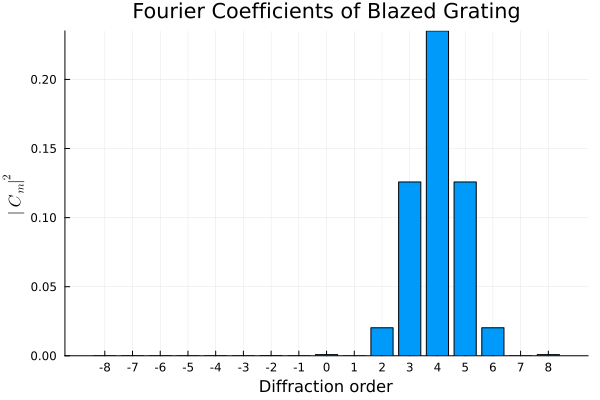

In [221]:
N = 2^11
ctr = N ÷ 2 + 1
p = 1
width = 8
modes = collect(-width:1:width) .+ ctr
mode_labels = collect(-width:1:width)
g1 = blazed_grating_1d(N, p, 0.5; thickness=500, mill_depth=200)
t1 = transmission_func(g1, false)
t1./= N
t1_fft = fftshift(fft(ifftshift(t1)))
t1_fft = circshift(t1_fft, 4)
# mask = collect(1:1:N÷2)
# t1_fft[mask] .= 0
# t1_fft ./=sqrt(sum(abs2, t1_fft))
println(sum(abs2.(t1_fft)))
bar(modes, abs2.(t1_fft)[modes],
    xlabel="Diffraction order", 
    ylabel=L"|C_m|^2",
    title="Fourier Coefficients of Blazed Grating",
    legend=false,
    xticks=(modes, mode_labels)
)
# ylims!(0, sum(abs2.(t1_fft)))

\begin{equation}
    \psi_k \propto \sum_m C_{m+k}^{t_3} C_{m}^{t_1} t_{2,m}
\end{equation}

In [468]:
function cross_correlation_FC(c_t3, c_t1, t2, k)
    N = length(c_t3)
    ctr = N ÷ 2 + 1
    local c_t3_shifted = circshift(c_t3, -k)
    local prod = @. c_t3_shifted * c_t1 * t2
    prod_sum = sum(prod)
    # unit_vec = (real(prod_sum) + 1im * imag(prod_sum)) / abs(prod_sum)

    coefficient_selected = abs2(c_t3[ctr] * c_t1[ctr-k] * t2[ctr-k])
    # dot_product = real(coefficient_selected) * real(unit_vec) + imag(coefficient_selected) * imag(unit_vec)
    # dot_product /= abs(prod_sum)
    return abs2(prod_sum), coefficient_selected/abs2(prod_sum)
end



function ψ_modes_setup(N,p, x_apex ; thickness=500,mill_depths, phase_shift=0, mode_blocking=false)
    g1st = blazed_grating_1d(N, p, x_apex; thickness=thickness, mill_depth=mill_depths[1])
    g2nd = blazed_grating_1d(N, p, x_apex; thickness=thickness, mill_depth=mill_depths[2])
    t1st = transmission_func(g1st, false)
    t3rd = transmission_func(g2nd, false)
    t1st ./= N
    t3rd ./= N
    t1st_fft = fftshift(fft(ifftshift(t1st)))
    t3rd_fft = fftshift(fft(ifftshift(t3rd)))

    if mode_blocking
        mask = collect(1:1:N÷2)
        t1st_fft[mask] .= 0
        t1st_fft ./=sqrt(sum(abs2, t1st_fft))
    end
        

    return t1st_fft, t3rd_fft

end

ψ_modes_setup (generic function with 1 method)

In [469]:
x_apex = 0.6
phase_shift = π/5
N_mill_depths = 19 + 1
t_2nd = ones(ComplexF64, N)
t_2nd[ctr + 1] = cis(phase_shift)
grating_1st_mill_depths = collect(range(1, 200, length = N_mill_depths))
phase_shifts = collect(range(0, 2π, length = 21))
x_apexes = collect(range(0.0, 1.0, length = 21))
prod_sums = zeros(Float64,length(phase_shifts), length(x_apexes), N_mill_depths, N_mill_depths)
ratios = zeros(Float64, length(phase_shifts), length(x_apexes), N_mill_depths, N_mill_depths)

for (i, md1) in enumerate(grating_1st_mill_depths)
    for (j, md2) in enumerate(grating_1st_mill_depths)
        for (k, ps) in enumerate(phase_shifts)
            for (l, xa) in enumerate(x_apexes)
                c_t1st, c_t3rd = ψ_modes_setup(N, p, xa; thickness=500, mill_depths=(md1, md2), phase_shift=ps, mode_blocking=true)    
                t_2nd[ctr + 1] = cis(ps)    
                prod_sum, ratio = cross_correlation_FC(c_t3rd, c_t1st, t_2nd, -1)
                prod_sums[k, l, i, j] = prod_sum
                ratios[k, l, i, j] = ratio
            end
        end
        
    end
end


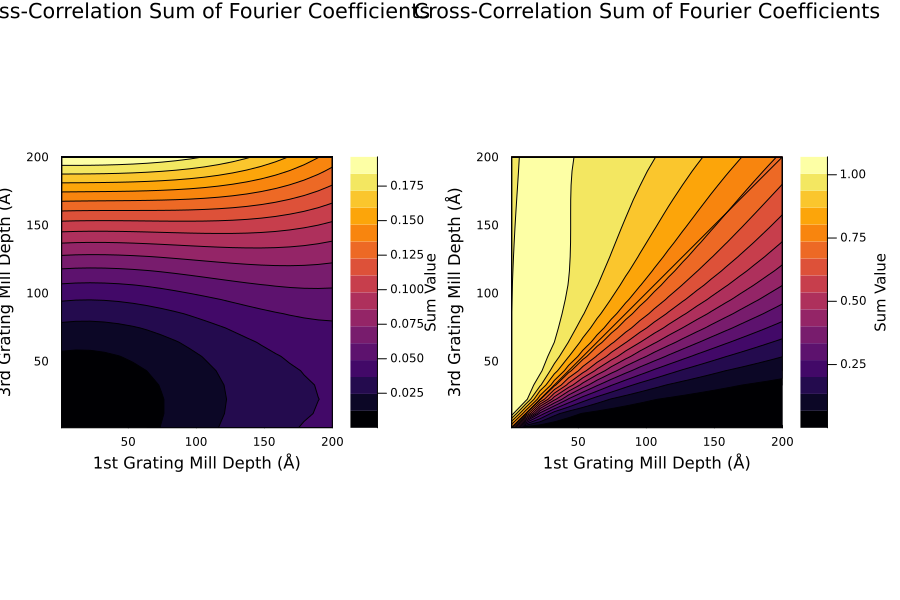

In [610]:
i,j = 15,19
fig1 =contourf(grating_1st_mill_depths, grating_1st_mill_depths, prod_sums[i, j, :, :];
    xlabel="1st Grating Mill Depth (Å)",
    ylabel="3rd Grating Mill Depth (Å)",
    title="Cross-Correlation Sum of Fourier Coefficients",
    colorbar_title="Sum Value",
    aspect_ratio=1,
    xlims=(minimum(grating_1st_mill_depths), maximum(grating_1st_mill_depths)),
    ylims=(minimum(grating_1st_mill_depths), maximum(grating_1st_mill_depths))
)   

fig2 = contourf(grating_1st_mill_depths, grating_1st_mill_depths, (ratios[i, j, :, :]);
    xlabel="1st Grating Mill Depth (Å)",
    ylabel="3rd Grating Mill Depth (Å)",
    title="Cross-Correlation Sum of Fourier Coefficients",
    colorbar_title="Sum Value",
    aspect_ratio=1,
    xlims=(minimum(grating_1st_mill_depths), maximum(grating_1st_mill_depths)),
    ylims=(minimum(grating_1st_mill_depths), maximum(grating_1st_mill_depths))
)
plot!(fig2, grating_1st_mill_depths, grating_1st_mill_depths, 
    label="", color=:black
)  
 
plot(fig1, fig2, layout=(1,2), size=(900,600))